**Loading Data And Looking At First Five Rows**

In [3]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv')
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

**Checking For Missing Values And Data Types**

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


**Data Cleaning**

In [10]:
df['country'] = df['country'].fillna('Unknown')
df.dropna(subset=['date_added','rating'] , inplace=True)
df['date_added']=pd.to_datetime(df['date_added'])
df['year_added']=df['date_added'].dt.year
df['month_added']=df['date_added'].dt.month_name()

**Separating Movies And TV Shows**

In [11]:
movies_df = df[df['type'] == 'Movie'].copy()
shows_df = df[df['type'] == 'TV Show'].copy()

**Droping Rows Where Duration Is Missing And Manipulating The Data**

In [13]:
movies_df = movies_df.dropna(subset=['duration'])

movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)

long_movies = movies_df[movies_df['duration_min'] > 120]
print(f"Number of movies longer than 2 hours: {len(long_movies)}")

Number of movies longer than 2 hours: 1142


**Finding The Most Common Number of Directors**

In [14]:
top_directors = df['director'].value_counts().head(10)
print(top_directors)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Jay Chapman               12
Youssef Chahine           12
Steven Spielberg          11
Name: count, dtype: int64


**Creating Table Where The Most Action Movies Are After 2015**

In [17]:
action_content = df[(df['listed_in'].str.contains('Action', case=False)) & (df['release_year'] > 2015)]
country_counts = action_content.groupby('country').size().sort_values(ascending=False).head(5)
print("Top 5 Countries for Action:")
print(country_counts)

Top 5 Countries for Action:
country
United States    156
India             44
Unknown           42
China             21
Japan             21
dtype: int64


**Simple Pie Chart**

<Axes: ylabel='count'>

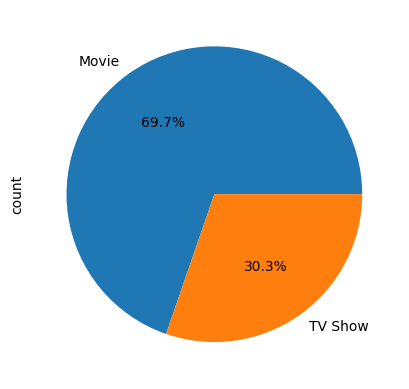

In [19]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')